# 고객 세그먼테이션(Customer Segmentation)
* 다양한 기준으로 고객을 분류하는 기법
* 타깃 마케팅을 위해 실행 -> 고객을 여러 특성에 맞게 세분화해 그 유형에 따라 맞춤형 마케팅/서비스 제공
* 고객의 어떤 요소를 기반으로 군집화할 것인가 결정하는 게 중요 -> 기본적 고객 분서 요소 RFM 기법 이용
  * Recency(R, 가장 최근 상품 구입일에서 오늘까지의 기간), Frequency(F, 상품 구매 횟수), Mometary Value(M, 총 구매금액)
* 온라인 판매 데이터를 기반으로 고객 세그멘테이션을 군집화 기반으로 수행하자

# 데이터세트 로딩과 데이터 클렌징
* 데이터셋 분석
  * 제품 주문 데이터셋임
  * Invoice(주문번호) + StockCode(제품 코드) 기반으로 주문량, 주문일자, 제품단가, 주문 고객 번호, 주문 고객 국가 등의 칼럼으로 구성
  * 주분번호 열 데이터 중 C로 시작하는 것은 취소 주문

In [2]:
import pandas as pd
import datetime
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#데이터 불러오기
retail_df = pd.read_excel(io='../online_retail/Online Retail.xlsx')
retail_df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [3]:
# 데이터 세트의 전체 건수, 칼럼 타입, Null 개수 확인
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


* 전체 데이터는 541,909개
* CustomerID의 Null값이 너무 많음, 그 외에도 오류 데이터 존재 -> 사전 정제 작업 필요
* 데이터 정제 작업
  * Null 데이터 제거 ; CustomerID에서 고객 식별번호가 없는 데이터는 필요 없기에 삭제
  * 오류 데이터 삭제 : Quantity UnitPrice가 0보다 작은 데이터가 대표적 오류 데이터(반환을 뜻함)->C로 InvoiceNo가 시작함 -> 분석 효율 위해 삭제

In [4]:
#불린 인덱싱 적용해 Quantitiy>0 & UnitPrice>0, CustomerID==NotNull 인것만 필터링

retail_df = retail_df[retail_df['Quantity']>0]
retail_df = retail_df[retail_df['UnitPrice']>0]
retail_df = retail_df[retail_df['CustomerID'].notnull()]
print(retail_df.shape)
retail_df.isnull().sum()

(397884, 8)


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [8]:
# 주요 주문 고객들은 국가 확인

retail_df['Country'].value_counts()[:5]

United Kingdom    354321
Name: Country, dtype: int64

In [9]:
# 주요 주문 고객들은 영국이니, 그외 나라들 제외하기

retail_df = retail_df[retail_df['Country']=='United Kingdom']
print(retail_df.shape)

(354321, 8)


# RFM 기반 데이터 제공
* 고객 세그멘테이션 군집화를 RFM 기반으로 수행하고자. 이를 위해 필요한 데이터를 가공하자
* 해당 데이터셋은 주문 횟수와 주문 금액이 압도적으로 특정 고객에게 많은 특성 있음 -> 소매점의 주문이 포함되어 있기 때문

In [10]:
#UnitPrice*Quantity 해서 주문 금액 데이터 만들기
retail_df['sale_amount'] = retail_df['Quantity'] * retail_df['UnitPrice']
#CustomerNo를 int형으로 만들어 편리한 식별성
retail_df['CustomerID'] = retail_df['CustomerID'].astype(int)

In [12]:
#상위 5개 주문 건수와 금액을 가진 고객 데이터 추출
print(retail_df['CustomerID'].value_counts().head(5))
print(retail_df.groupby('CustomerID')['sale_amount'].sum().sort_values(ascending=False)[:5])

17841    7847
14096    5111
12748    4595
14606    2700
15311    2379
Name: CustomerID, dtype: int64
CustomerID
18102    259657.30
17450    194550.79
16446    168472.50
17511     91062.38
16029     81024.84
Name: sale_amount, dtype: float64


In [13]:
#해당 데이터셋은 주문번호+상품코드 레벨의 식별자로 되어 있음
retail_df.groupby(['InvoiceNo', 'StockCode'])['InvoiceNo'].count().mean()
#InvoiceNum + StockCode 로 groupby를 수행하면 거의 1에 가깝게 유일한 식별자 레벨이 됨

1.028702077315023

* RFM 기반 고객 세그먼테이션은 고객 레벨로 주문 기간, 횟수, 금액 데이터를 기반으로 해 세그먼테이션 수행해야 함
* 따라서 주문번호+상품코드 기준 데이터 --> 고객 기준의 R,F,M 데이터로 변경해야 함
* 따라서 주문 번호 기준의 데이터를 개별 고객 기준의 데이터로 groupby 해야 함

* dataframe의 groupby()만 사용해서는 여러 개의 칼럼에 서로 다른 aggregation 연산(count, max 등) 한 번에 수행하기 어려움
* dataframe에 groupby를 호출해 반환된 DataFrameGroupby 객체에 agg() 이용하자
* agg() 인자로 대상 칼럼들과 aggregation 함수명들을 딕셔너리 형태로 입력->칼럼 여러 개의 agg 연산 수행 가능
* Frequency : 고객별 주문 건수 -> CustomerID로 groupby해서 InvoiceNo의 count()로 구함
* MonetaryValue : 고객별 주문 금액 -> CustomerID로 groupby해서 sale_amount의 sum()으로 구함
* Recency
  * CustomerID로 groupby해서 InvoideDate 칼럼의 max로 가장 최근 주문 일자 구함
  * -> 가장 최근 날짜 = 오늘 날짜 기준으로 가장 최근 주문 일자
  * 이 때 '오늘 날짜'를 현재 날짜로 해선 안됨. 데이터가 2010/12/1 ~ 2011/12/9까지이므로 2011/12/10을 기준으로
  * 가장 최근의 주문 일자를 뺀 데이터에서 일자 데이터(days)만 추출해 생성

In [17]:
aggregations = {
    'InvoiceDate' : 'max',
    'InvoiceNo' : 'count',
    'sale_amount' : 'sum'
}
cust_df = retail_df.groupby('CustomerID').agg(aggregations)
#groupby된 결과 칼럼 값을 R, F, M으로 변경
cust_df = cust_df.rename(columns={'InvoiceDate':'Recency',
                                'InvoiceNo':'Frequency',
                                'sale_amount':'Monetary'})
cust_df = cust_df.reset_index()
cust_df.head(3)

,CustomerID,Recency,Frequency,Monetary
0,12346,2011-01-18 10:01:00,1,77183.60
1,12747,2011-12-07 14:34:00,103,4196.01
2,12748,2011-12-09 12:20:00,4595,33719.73


In [18]:
import datetime as dt

cust_df['Recency'] = dt.datetime(2011, 12, 10) - cust_df['Recency']
cust_df['Recency'] = cust_df['Recency'].apply(lambda x: x.days+1)
print('cust_df 로우와 칼럼의 건수', cust_df.shape)
cust_df.head(3)

cust_df 로우와 칼럼의 건수 (3920, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12747,3,103,4196.01
2,12748,1,4595,33719.73


# RFM 기반 고객 세그먼테이션
* 소매업체의 대규모 주문까지 포함되어 왜곡된 데이터 분포 가짐 -> 군집화가 한쪽에만 집중
* 온라인 판매 데이터셋의 칼럼별 히스토그램 확인 -> 왜곡되었을 때 어떤 군집화 현상 발생하는지 알아보자

(array([3.887e+03, 1.900e+01, 9.000e+00, 2.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00]),
 array([3.75000000e+00, 2.59691050e+04, 5.19344600e+04, 7.78998150e+04,
        1.03865170e+05, 1.29830525e+05, 1.55795880e+05, 1.81761235e+05,
        2.07726590e+05, 2.33691945e+05, 2.59657300e+05]),
 <a list of 10 Patch objects>)

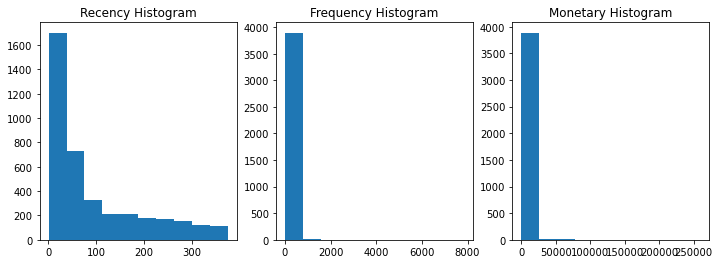

In [20]:
fig, (ax1, ax2, ax3) = plt.subplots(figsize=(12, 4), nrows=1, ncols=3)
ax1.set_title('Recency Histogram')
ax1.hist(cust_df['Recency'])
ax2.set_title('Frequency Histogram')
ax2.hist(cust_df['Frequency'])
ax3.set_title('Monetary Histogram')
ax3.hist(cust_df['Monetary'])

In [21]:
# 칼럼의 데이터값 백분위로 분포 확인

cust_df[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,3920.000000,3920.000000,3920.000000
mean,92.742092,90.388010,1864.385601
std,99.533485,217.808385,7482.817477
min,1.000000,1.000000,3.750000
25%,18.000000,17.000000,300.280000
50%,51.000000,41.000000,652.280000
75%,143.000000,99.250000,1576.585000
max,374.000000,7847.000000,259657.300000


* 50%인 중위값보다 크게 평균이 높음. max가 75%보다 훨씬 큼 -> 왜곡 정도 심함
* max 값 등 상위 몇 개의 큰 값으로 인한 것
* 왜곡 정도가 매우 높은 데이터셋에 K-평균 군집을 적용 시, 중심 개수 증가시켜도 변별력 떨어지는 군집화가 됨

In [23]:
# 데이터셋을 StandardScaler로 평균과 표준편차를 재조정한 뒤, K-평균 수행

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

x_features = cust_df[['Recency', 'Frequency', 'Monetary']].values
x_features_scaled = StandardScaler().fit_transform(x_features)

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(x_features_scaled)
cust_df['cluster_label'] = labels

print('실루엣 스코어 : {0:.3f}'.format(silhouette_score(x_features_scaled, labels)))

실루엣 스코어 : 0.592


* 전체 군집의 평균 실루엣 계수인 실루엣 스코어는 안정적임
* 각 군집별 실루엣 계수 값은 그리 좋지 않음(코드 생략함) : 군집 개수를 2~5개로 변화시키며 확인

* 크게 왜곡된 데이터셋 도출은 굳이 군집화 이용 않고도 간단 데이터 분석으로도 충분히 가능
* 지나치게 왜곡된 데이터는 K-평균 같은 거리 기반 군집화 알고리즘에서 지나치게 일반적 군집화 결과 도출함

* 군집화는 비지도 학습 알고리즘의 하나로, 숨어 있는 새로운 집단을 발견하고자 함 -> 새로운 군집 내 데이터값을 분석&이해해 이 집단에 새로운 의미 부여 -> 전체 데이터를 다른 각도로 바라보게 함

* 로그 변환 : 데이터셋의 왜곡 정도 낮추려 가장 많이 사용되는 방법. 데이터값에 log 적용하는 것

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

cust_df['Recency_log'] = np.log1p(cust_df['Recency'])
cust_df['Frequency_log'] = np.log1p(cust_df['Frequency'])
cust_df['Monetary_log'] = np.log1p(cust_df['Monetary'])

x_features = cust_df[['Recency_log', 'Frequency_log', 'Monetary_log']].values
x_features_scaled = StandardScaler().fit_transform(x_features)

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(x_features_scaled)
cust_df['cluster_label'] = labels

print('실루엣 스코어 : {0:.3f}'.format(silhouette_score(x_features_scaled, labels)))

실루엣 스코어 : 0.303


* 로그 변환 전보다 실루엣 스코어는 떨어지지만, 개별 군집이 더 균일하게 나눠짐
* 즉, 이렇게 왜곡된 데이터셋에 대해서 로그 변환으로 데이터를 일차 변환한 후 군집화 수행하면 더 나은 결과 나옴